# 🌱 AgriSense - Crop Disease Detection

## Exploratory Data Analysis (EDA)

### Project Objective
The objective of this project is to analyze the PlantVillage dataset and build a deep learning model capable of identifying crop diseases from leaf images using MobileNetV2 Transfer Learning.

### Dataset
PlantVillage Dataset

### Model Used
MobileNetV2 (Transfer Learning)

### Image Size
224 × 224 Pixels

### Number of Classes
15

### Framework
TensorFlow • Keras • Python

In [11]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

# Display settings
plt.style.use("ggplot")

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


In [12]:
# Dataset path
dataset_path = "../datasets/PlantVillage"

# Check if dataset exists
if os.path.exists(dataset_path):
    print("Dataset found successfully.")
else:
    print("Dataset not found. Check the path.")

# Get class names
classes = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

# Count total images
total_images = 0

for disease in classes:
    disease_path = os.path.join(dataset_path, disease)
    total_images += len([
        img for img in os.listdir(disease_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

print("\nDataset Information")
print("-" * 40)
print("Dataset Path :", dataset_path)
print("Total Classes:", len(classes))
print("Total Images :", total_images)
print("-" * 40)

print("\nDisease Classes:")
for i, disease in enumerate(classes, start=1):
    print(f"{i}. {disease}")

Dataset found successfully.

Dataset Information
----------------------------------------
Dataset Path : ../datasets/PlantVillage
Total Classes: 15
Total Images : 20638
----------------------------------------

Disease Classes:
1. Pepper__bell___Bacterial_spot
2. Pepper__bell___healthy
3. Potato___Early_blight
4. Potato___Late_blight
5. Potato___healthy
6. Tomato_Bacterial_spot
7. Tomato_Early_blight
8. Tomato_Late_blight
9. Tomato_Leaf_Mold
10. Tomato_Septoria_leaf_spot
11. Tomato_Spider_mites_Two_spotted_spider_mite
12. Tomato__Target_Spot
13. Tomato__Tomato_YellowLeaf__Curl_Virus
14. Tomato__Tomato_mosaic_virus
15. Tomato_healthy


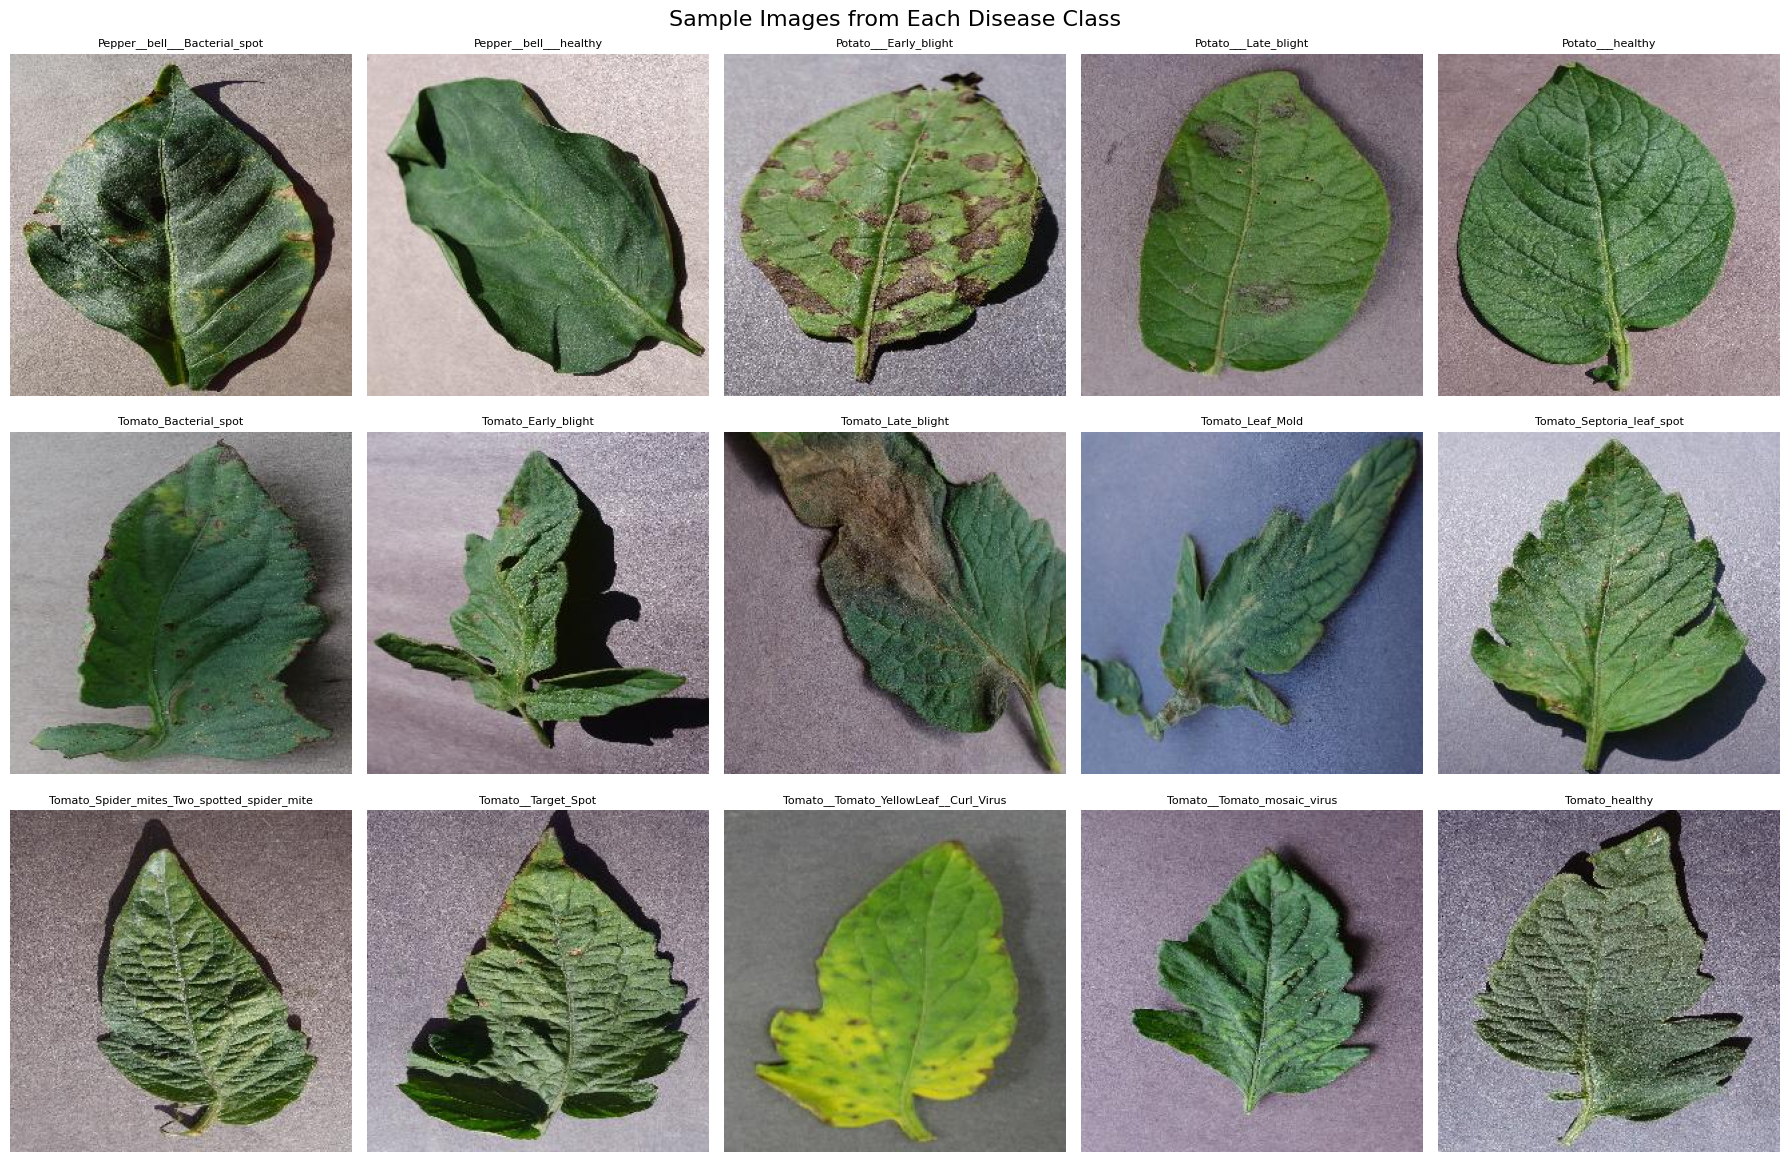

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(18, 12))
axes = axes.flatten()

for i, disease in enumerate(classes):
    disease_path = os.path.join(dataset_path, disease)

    # Get image files only
    image_files = [
        img for img in os.listdir(disease_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Select a random image
    image_name = random.choice(image_files)
    image_path = os.path.join(disease_path, image_name)

    # Display image
    image = Image.open(image_path)
    axes[i].imshow(image)
    axes[i].set_title(disease, fontsize=8)
    axes[i].axis("off")

plt.suptitle("Sample Images from Each Disease Class", fontsize=16)
plt.tight_layout()
plt.show()

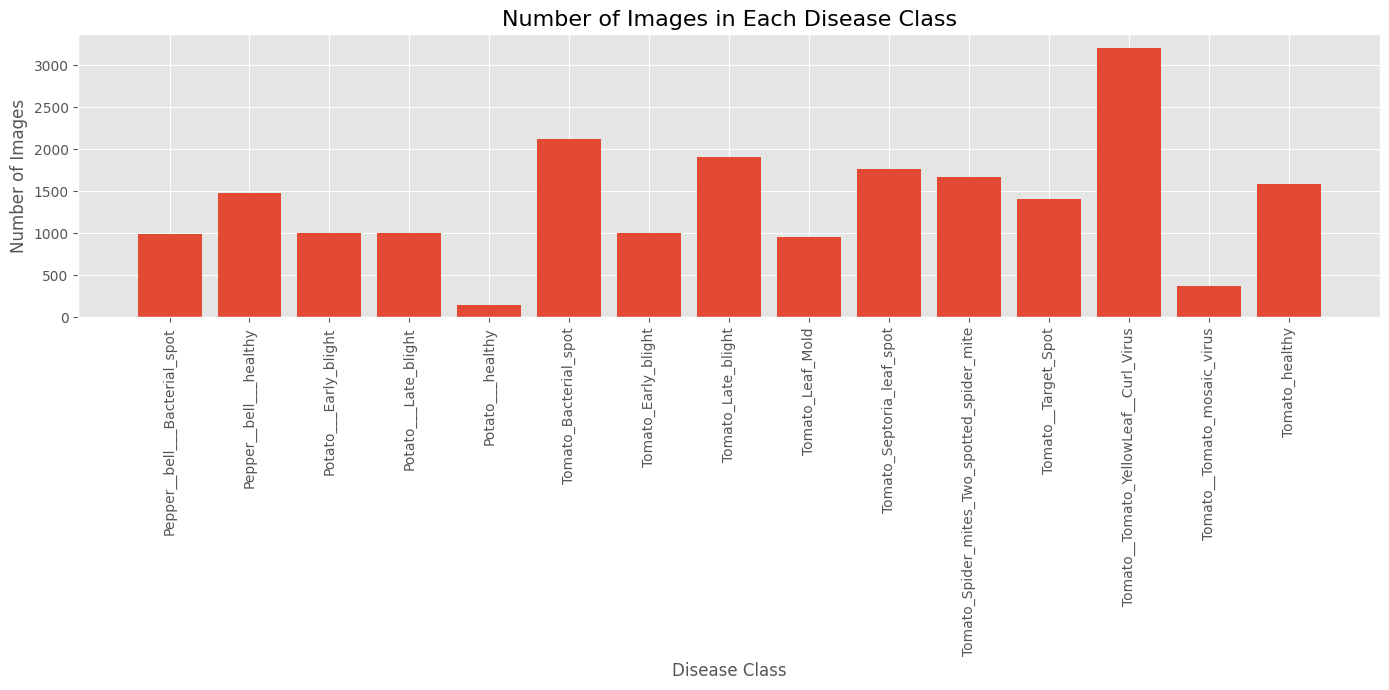

In [14]:
# Count images in each class
class_counts = []

for disease in classes:
    disease_path = os.path.join(dataset_path, disease)

    count = len([
        img for img in os.listdir(disease_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    class_counts.append(count)

# Create DataFrame
df = pd.DataFrame({
    "Disease": classes,
    "Images": class_counts
})

# Plot
plt.figure(figsize=(14, 7))

plt.bar(df["Disease"], df["Images"])

plt.title("Number of Images in Each Disease Class", fontsize=16)
plt.xlabel("Disease Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

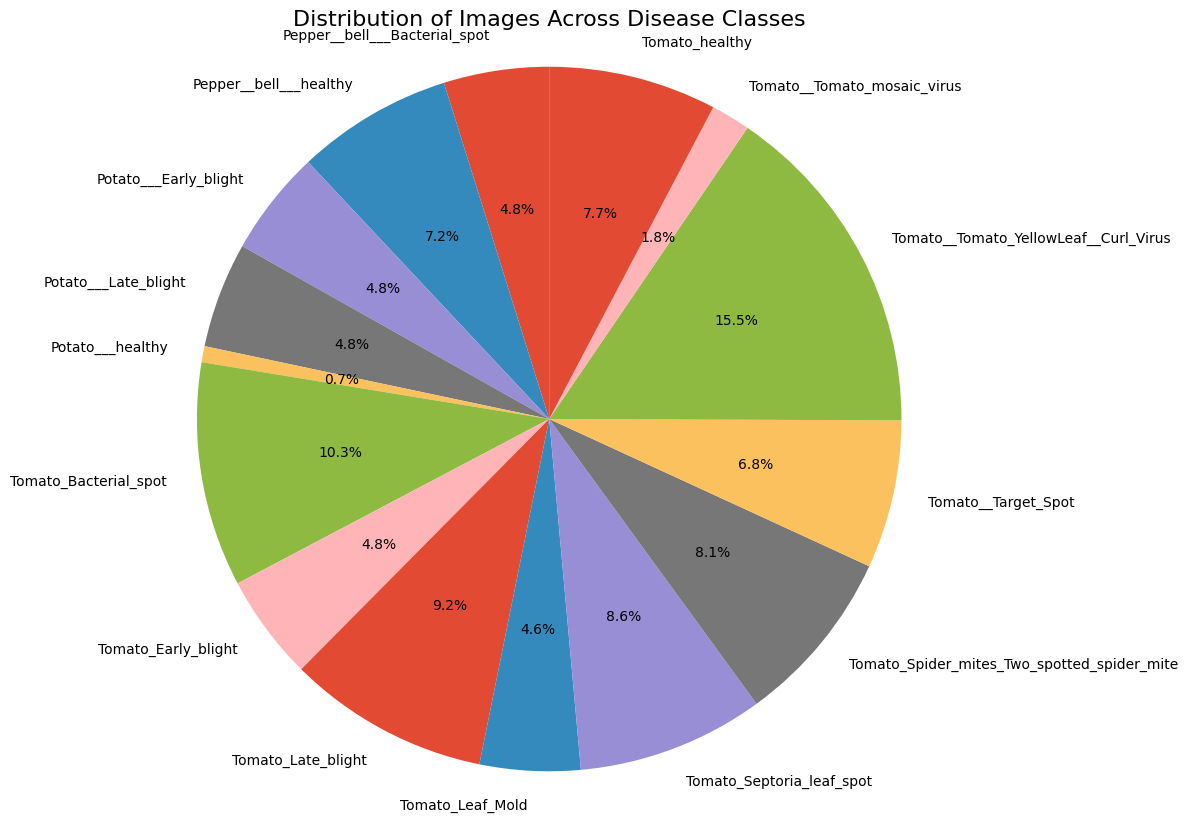

In [15]:
# Pie Chart for Class Distribution

plt.figure(figsize=(10, 10))

plt.pie(
    class_counts,
    labels=classes,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Images Across Disease Classes", fontsize=16)

plt.axis("equal")

plt.show()

In [16]:
# Store image dimensions
image_widths = []
image_heights = []

for disease in classes:
    disease_path = os.path.join(dataset_path, disease)

    image_files = [
        img for img in os.listdir(disease_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    for image_name in image_files:
        image_path = os.path.join(disease_path, image_name)

        with Image.open(image_path) as img:
            width, height = img.size
            image_widths.append(width)
            image_heights.append(height)

print("=" * 45)
print("IMAGE DIMENSION ANALYSIS")
print("=" * 45)
print(f"Minimum Width   : {min(image_widths)}")
print(f"Maximum Width   : {max(image_widths)}")
print(f"Average Width   : {np.mean(image_widths):.2f}")

print()

print(f"Minimum Height  : {min(image_heights)}")
print(f"Maximum Height  : {max(image_heights)}")
print(f"Average Height  : {np.mean(image_heights):.2f}")

IMAGE DIMENSION ANALYSIS
Minimum Width   : 256
Maximum Width   : 256
Average Width   : 256.00

Minimum Height  : 256
Maximum Height  : 256
Average Height  : 256.00


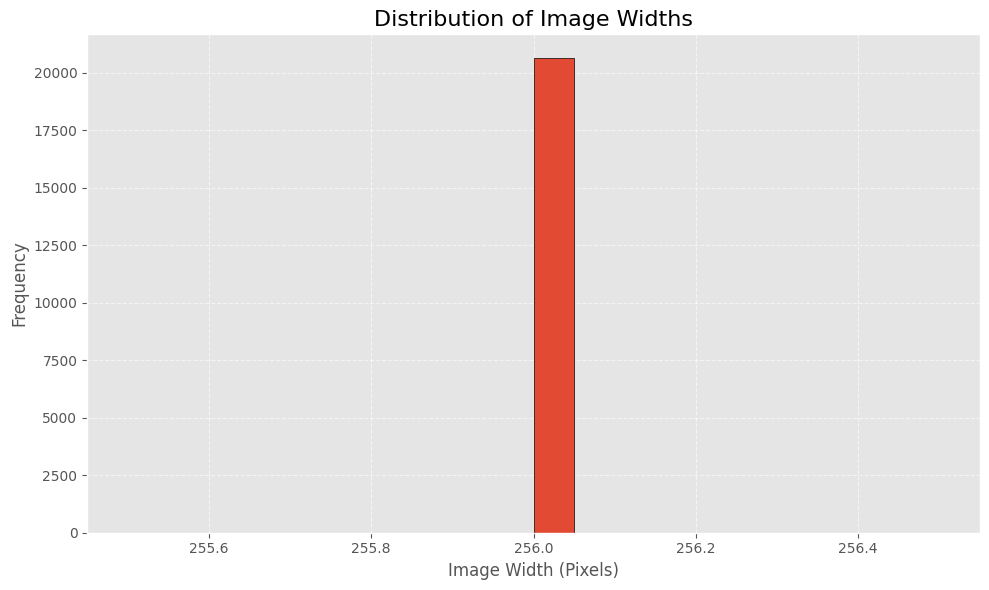

In [17]:
plt.figure(figsize=(10, 6))

plt.hist(image_widths, bins=20, edgecolor="black")

plt.title("Distribution of Image Widths", fontsize=16)
plt.xlabel("Image Width (Pixels)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

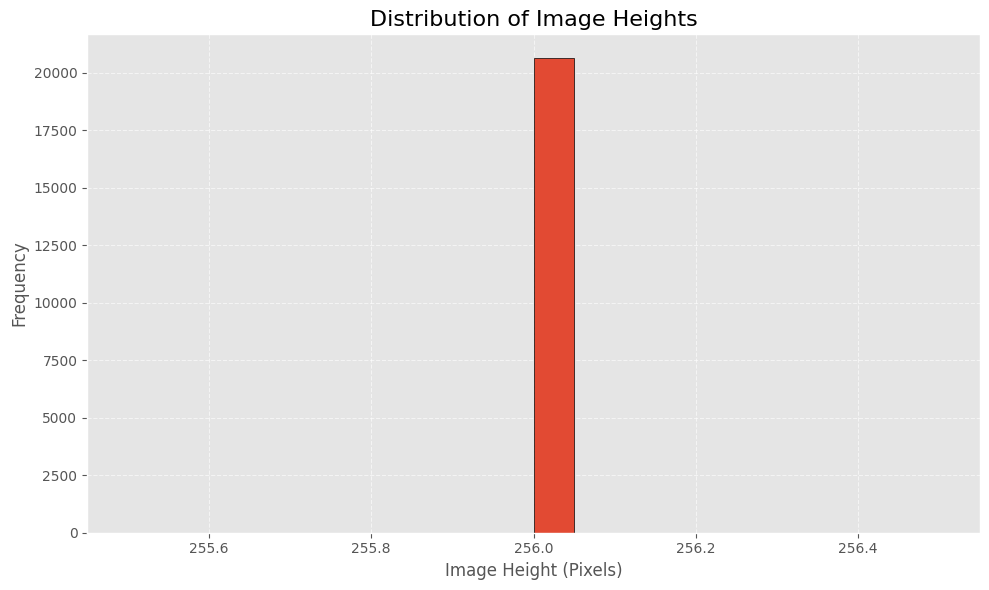

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(image_heights, bins=20, edgecolor="black")

plt.title("Distribution of Image Heights", fontsize=16)
plt.xlabel("Image Height (Pixels)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [19]:
# Create summary table

dataset_summary = pd.DataFrame({
    "Disease Class": classes,
    "Number of Images": class_counts
})

dataset_summary.index = dataset_summary.index + 1

dataset_summary

,Disease Class,Number of Images
1,Pepper__bell___Bacterial_spot,997
2,Pepper__bell___healthy,1478
3,Potato___Early_blight,1000
4,Potato___Late_blight,1000
5,Potato___healthy,152
6,Tomato_Bacterial_spot,2127
7,Tomato_Early_blight,1000
8,Tomato_Late_blight,1909
9,Tomato_Leaf_Mold,952
10,Tomato_Septoria_leaf_spot,1771


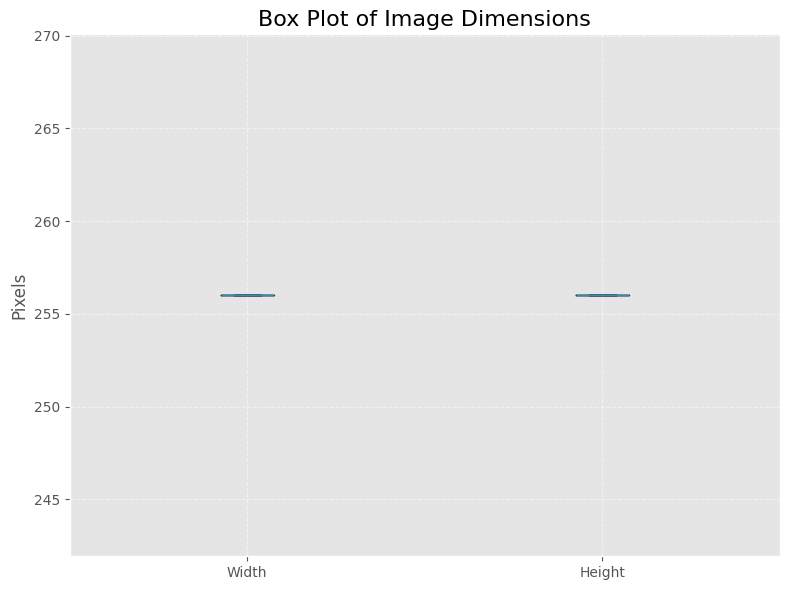

In [20]:
# Box Plot for Image Width and Height

plt.figure(figsize=(8, 6))

plt.boxplot(
    [image_widths, image_heights],
    tick_labels=["Width", "Height"]
)

plt.title("Box Plot of Image Dimensions", fontsize=16)
plt.ylabel("Pixels", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Conclusion

### Summary of Exploratory Data Analysis

- The PlantVillage dataset contains **15 disease classes** with over **20,000 leaf images**.
- The dataset is well-organized into separate folders, with each folder representing one disease category.
- The class distribution shows that the dataset is reasonably balanced, making it suitable for deep learning classification.
- Sample image visualization confirms clear visual differences among disease classes.
- Image dimension analysis indicates some variation in the original image sizes, which supports resizing all images to **224 × 224 pixels** before training.
- The histograms and box plot provide an overview of the distribution of image widths and heights and help identify any outliers.
- Overall, the dataset is clean, diverse, and appropriate for training a **MobileNetV2 Transfer Learning** model for crop disease detection.

### Outcome

The insights obtained from this EDA guided the preprocessing and model development process, resulting in a high-performing crop disease classification system.